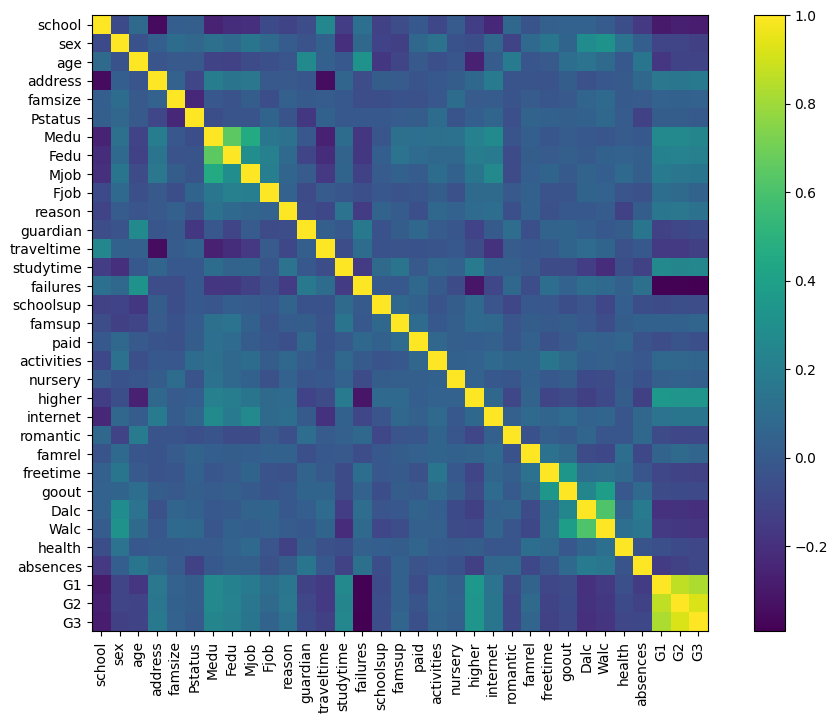

MAE : 0.6996219992778999
MSE : 1.3320183399137377
RMSE : 1.1541309890622198
R2 Score : 0.8634067744439324


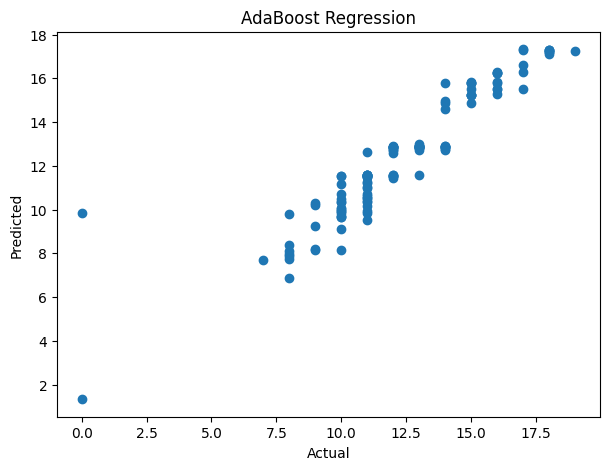

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import joblib

# Visualization
import matplotlib.pyplot as plt

# Sklearn modules
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Read dataset
df = pd.read_csv("student-por.csv")

# Show dataset
df.head()

# Remove duplicates
df = df.drop_duplicates()

# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Categorical columns
cat_cols = df.select_dtypes(include="object").columns

# Fill missing numerical values
num_imputer = SimpleImputer(strategy="mean")
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Fill missing categorical values
if len(cat_cols) > 0:

    cat_imputer = SimpleImputer(
        strategy="most_frequent"
    )

    df[cat_cols] = cat_imputer.fit_transform(
        df[cat_cols]
    )

# Encode categorical columns
encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col]
    )

    encoders[col] = le

# Correlation matrix
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
plt.imshow(corr)
plt.colorbar()
plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)
plt.yticks(
    range(len(corr.columns)),
    corr.columns
)
plt.show()

# Features
X = df.drop("G3", axis=1)

# Target
y = df["G3"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale dataset
scaler = StandardScaler()

# Fit train data
X_train_scaled = scaler.fit_transform(
    X_train
)

# Transform test data
X_test_scaled = scaler.transform(
    X_test
)

# Base estimator
base_model = DecisionTreeRegressor(
    max_depth=4
)

# Parameter grid
param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.1, 1]
}

# Create model
ada = AdaBoostRegressor(
    estimator=base_model,
    random_state=42
)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=ada,
    param_grid=param_grid,
    cv=3,
    scoring="r2"
)

# Train model
grid_search.fit(
    X_train_scaled,
    y_train
)

# Best model
model = grid_search.best_estimator_

# Save model
joblib.dump(
    model,
    "models/adaboost_regressor.pkl"
)

# Save scaler
joblib.dump(
    scaler,
    "models/scaler.pkl"
)

# Predict output
y_pred = model.predict(
    X_test_scaled
)

# Metrics
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

# Print metrics
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

# Actual vs predicted
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("AdaBoost Regression")
plt.show()